# MoodNote-AI — Fine-tune PhoBERT trên Google Colab

Pipeline phân loại cảm xúc tiếng Việt với **PhoBERT + UIT-VSMEC + ViGoEmotions**.

**Trước khi chạy:**
1. Vào `Runtime → Change runtime type → T4 GPU`
2. Vào `Runtime → Manage Secrets` → thêm secret key **`HF_TOKEN`** (token HuggingFace của bạn)
3. Thay `REPO_URL` ở Cell 3 bằng URL GitHub của bạn
4. Chạy `Runtime → Run all`

## Cell 1 — Kiểm tra GPU

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "Không tìm thấy GPU!\n"
        "Vào Runtime → Change runtime type → chọn T4 GPU rồi chạy lại."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"GPU   : {gpu_name}")
print(f"VRAM  : {gpu_mem:.1f} GB")
print(f"PyTorch: {torch.__version__}")
print("Sẵn sàng train!")

GPU   : Tesla T4
VRAM  : 14.6 GB
PyTorch: 2.10.0+cu128
Sẵn sàng train!


## Cell 2 — Mount Google Drive

Model và checkpoint sẽ được lưu vào Drive để không mất khi session kết thúc.

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Tạo thư mục lưu trữ trong Drive
DRIVE_BASE = '/content/drive/MyDrive/MoodNote-AI'
os.makedirs(f'{DRIVE_BASE}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_BASE}/best_model',  exist_ok=True)

print(f"Drive mounted. Thư mục lưu: {DRIVE_BASE}")

Mounted at /content/drive
Drive mounted. Thư mục lưu: /content/drive/MyDrive/MoodNote-AI


## Cell 3 — Clone repo & cài dependencies

> **Thay `REPO_URL`** bằng URL GitHub của bạn, ví dụ:
> `https://github.com/username/MoodNote-AI.git`

In [3]:
import sys

REPO_URL  = 'https://github.com/ToanHuynh0201/MoodNote-AI.git'  # <-- ĐỔI Ở ĐÂY
REPO_DIR  = '/content/MoodNote-AI'

# Clone repo
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repo đã tồn tại tại {REPO_DIR}, bỏ qua clone.")
    !cd {REPO_DIR} && git pull

# Thêm vào Python path
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Cài dependencies
print("\nCài đặt dependencies...")
!pip install -r {REPO_DIR}/requirements.txt -q

# Cài YAKE cho keyword extraction (FR-13)
print("Cài đặt YAKE...")
!pip install yake -q

print("\nHoàn tất cài đặt!")

Cloning into '/content/MoodNote-AI'...
remote: Enumerating objects: 386, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 386 (delta 0), reused 2 (delta 0), pack-reused 380 (from 1)
Receiving objects: 100% (386/386), 137.71 KiB | 1.13 MiB/s, done.
Resolving deltas: 100% (239/239), done.

Cài đặt dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Cell 4 — Cấu hình paths cho Colab

In [4]:
import os

# --- Paths ---
REPO_DIR       = '/content/MoodNote-AI'
CONFIG_DIR     = f'{REPO_DIR}/configs'
RAW_DIR        = f'{REPO_DIR}/data/raw'
MERGED_DIR     = f'{REPO_DIR}/data/merged'
PROCESSED_DIR  = f'{REPO_DIR}/data/processed'
CHECKPOINT_DIR = f'{DRIVE_BASE}/checkpoints'
BEST_MODEL_DIR = f'{DRIVE_BASE}/best_model'

os.makedirs(RAW_DIR,       exist_ok=True)
os.makedirs(MERGED_DIR,    exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# --- Tắt W&B ---
os.environ['WANDB_MODE']    = 'disabled'
os.environ['WANDB_SILENT']  = 'true'

print("Paths đã cấu hình:")
print(f"  Config     : {CONFIG_DIR}")
print(f"  Data raw   : {RAW_DIR}")
print(f"  Merged     : {MERGED_DIR}")
print(f"  Processed  : {PROCESSED_DIR}")
print(f"  Checkpoints: {CHECKPOINT_DIR}")
print(f"  Best model : {BEST_MODEL_DIR}")
print("  W&B        : disabled")

Paths đã cấu hình:
  Config     : /content/MoodNote-AI/configs
  Data raw   : /content/MoodNote-AI/data/raw
  Merged     : /content/MoodNote-AI/data/merged
  Processed  : /content/MoodNote-AI/data/processed
  Checkpoints: /content/drive/MyDrive/MoodNote-AI/checkpoints
  Best model : /content/drive/MyDrive/MoodNote-AI/best_model
  W&B        : disabled


## Cell 5 — Download UIT-VSMEC

In [5]:
import os
os.chdir(REPO_DIR)

from src.data.download_dataset import download_uit_vsmec

print("=" * 50)
print("Bước 1: Download UIT-VSMEC")
print("=" * 50)
download_uit_vsmec(output_dir=RAW_DIR)

import pandas as pd
for split in ['train', 'validation', 'test']:
    f = f'{RAW_DIR}/{split}.csv'
    df = pd.read_csv(f)
    print(f"  {split:12s}: {len(df):,} mẫu")

Bước 1: Download UIT-VSMEC


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5548 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/693 [00:00<?, ? examples/s]

Dataset loaded successfully!
Train samples: 5548
Validation samples: 686
Test samples: 693
Saved train split to /content/MoodNote-AI/data/raw/train.csv

Sample from train:
                                            Sentence  Emotion
0              cho mình xin bài nhạc tên là gì với ạ    Other
1  cho đáng đời con quỷ . về nhà lôi con nhà mày ...  Disgust

Saved validation split to /content/MoodNote-AI/data/raw/validation.csv

Sample from validation:
                                            Sentence    Emotion
0  tính tao tao biết , chẳng có chuyện gì có thể ...      Other
1           lại là lào cai , tự hào quê mình quá :))  Enjoyment

Saved test split to /content/MoodNote-AI/data/raw/test.csv

Sample from test:
                                    Sentence   Emotion
0           người ta có bạn bè nhìn vui thật   Sadness
1  cho nghỉ viêc mói đúng sao goi là kỷ luật  Surprise


Emotion distribution in training set:
Anger: 391 (7.05%)
Disgust: 1071 (19.30%)
Enjoyment: 1558 (28.08%)
Fe

## Cell 5.2 — Download ViGoEmotions (gated dataset)

> **Trước khi chạy:** vào `Runtime → Manage Secrets` → thêm secret với key **`HF_TOKEN`** và value là HuggingFace token của bạn (lấy tại [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)).

In [6]:
import os
os.chdir(REPO_DIR)

# Đọc HF token từ Colab Secrets (Runtime → Manage Secrets → thêm key "HF_TOKEN")
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
    print("HF token loaded from Colab Secrets.")
except Exception:
    HF_TOKEN = None
    print("Warning: Không lấy được token từ Colab Secrets.")
    print("Nếu download thất bại, thêm secret 'HF_TOKEN' trong Runtime → Manage Secrets.")

from src.data.download_vigoemotions import download_vigoemotions

print("\n" + "=" * 50)
print("Bước 2: Download ViGoEmotions")
print("=" * 50)
download_vigoemotions(output_dir=RAW_DIR, token=HF_TOKEN)

HF token loaded from Colab Secrets.

Bước 2: Download ViGoEmotions
  Using provided HuggingFace token.


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16531 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2067 [00:00<?, ? examples/s]

Dataset loaded successfully!

train: 16531 samples | columns: ['id', 'text', 'labels']
  Detected label format: list_column
  Saved to /content/MoodNote-AI/data/raw/vigoemotions/train.csv
  Sample row:
    text:   Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí
    labels: ['embarrassment']

validation: 2066 samples | columns: ['id', 'text', 'labels']
  Detected label format: list_column
  Saved to /content/MoodNote-AI/data/raw/vigoemotions/validation.csv
  Sample row:
    text:   Buồn nốt tý dở thui nghen🥲🤩
    labels: ['admiration', 'amusement', 'optimism']

test: 2067 samples | columns: ['id', 'text', 'labels']
  Detected label format: list_column
  Saved to /content/MoodNote-AI/data/raw/vigoemotions/test.csv
  Sample row:
    text:   Ko coi p1 đi xem p2 thì đc ko ta Mai Huệ
    labels: ['fear']

Total samples: 20664
Avg labels per sample: 1.91

Top 15 most common fine-grained labels (across all splits):
  admiration          :  3569
  optimism      

{'train':                                                     text  \
 0      Xem mà ngẫm lại cuộc đời bản thân ta đã trải q...   
 1                                    bức ảnh xuất sắc ❤️   
 2      Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố là...   
 3      Bài học: <br>1: 5 nhìn, 4 chạm, 3 nghe, 2 ngửi...   
 4      Dima Egiazarov bởi vì chúng tôi là người Việt ...   
 ...                                                  ...   
 16526                                 tự dưng cay mẹ mắt   
 16527  per đã nhẫn nhịn lắm ... đến khi con sen tao c...   
 16528  Trời ơi, xem tin hôm qua giờ mà không biết là ...   
 16529  Nếu có thể quay lại tôi thề ngày hôm ấy tôi sẽ...   
 16530  @nangoc84 Sở hữu #Pi là lối thoát cho người ng...   
 
                                   labels  
 0                        [embarrassment]  
 1             [anger, desire, annoyance]  
 2                    [desire, curiosity]  
 3                             [surprise]  
 4                  [relief, realizat

## Cell 5.3 — Merge UIT-VSMEC + ViGoEmotions

Gộp 2 dataset thành một:
- **train / validation**: VSMEC + ViGoEmotions (mapped + deduplicated)
- **test**: VSMEC only (giữ clean benchmark)

In [7]:
import os
os.chdir(REPO_DIR)

from src.data.merge_datasets import main as merge_main

print("=" * 50)
print("Bước 3: Merge UIT-VSMEC + ViGoEmotions")
print("=" * 50)
merge_main(
    vsmec_dir=RAW_DIR,
    vigoemotions_dir=f'{RAW_DIR}/vigoemotions',
    output_dir=MERGED_DIR,
)

Bước 3: Merge UIT-VSMEC + ViGoEmotions
Starting dataset merge: UIT-VSMEC + ViGoEmotions
  VSMEC source:       /content/MoodNote-AI/data/raw
  ViGoEmotions source:/content/MoodNote-AI/data/raw/vigoemotions
  Output:             /content/MoodNote-AI/data/merged
  Minority classes:   ['Anger', 'Disgust', 'Fear', 'Other', 'Surprise']
  Max per class:      {'Anger': 700, 'Fear': 500, 'Disgust': 300, 'Surprise': 900, 'Other': 250}

  TRAIN SPLIT MERGE REPORT
  VSMEC samples:              5548
  ViGoEmotions input:        16531
  ViGoEmotions resolved:      4884
  ViGoEmotions skipped:      11647  (70.5%)
  ViGoEmotions filtered:      3156  (64.6% — non-minority classes)
  ViGoEmotions deduped:        278  (5.7% of resolved)
  ViGoEmotions added:         1317

  Skipped sample examples (first 10):
    labels=['anger', 'desire', 'annoyance']  text=bức ảnh xuất sắc ❤️
    labels=['desire', 'curiosity']  text=Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố làm to
    labels=['relief', 'realization']

## Cell 5.4 — Preprocess merged dataset (word segmentation)

In [8]:
import os
os.chdir(REPO_DIR)

from src.data.preprocess import preprocess_dataset

print("=" * 50)
print("Bước 4: Preprocess (word segmentation)")
print("=" * 50)
preprocess_dataset(
    input_dir=MERGED_DIR,
    output_dir=PROCESSED_DIR,
    config_path=f'{CONFIG_DIR}/model_config.yaml'
)

import pandas as pd
for split in ['train', 'validation', 'test']:
    f = f'{PROCESSED_DIR}/{split}.csv'
    df = pd.read_csv(f)
    print(f"  {split:12s}: {len(df):,} mẫu — {f}")

Bước 4: Preprocess (word segmentation)
Starting Vietnamese text preprocessing...
Using segmenter: pyvi

Processing train split...
Loaded 6865 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting train: 100%|██████████| 6865/6865 [00:01<00:00, 5256.25it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/train.csv

Examples:

Original: phải có bao nhiêu tình cảm mới có thể viết ra được những dòng này ...
Segmented: phải có bao_nhiêu tình_cảm mới có_thể viết ra được những dòng này ...
Label: 1

Original: cần 1 thời gian dài thật dài nữa thì ý thức mới đi lên được
Segmented: cần 1 thời_gian dài thật dài nữa thì ý_thức mới đi lên được
Label: 6

Original: eo ....
Segmented: eo ... .
Label: 4

Processing validation split...
Loaded 914 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting validation: 100%|██████████| 914/914 [00:00<00:00, 4799.82it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/validation.csv

Examples:

Original: cũng có khi chơi với con gái ít vì nó quá xấu tính đéo con nào thèm chơi với nó , chỉ có thể chơi được với bọn con trai
Segmented: cũng có khi chơi với con_gái ít vì nó quá xấu_tính đéo con nào thèm chơi với nó , chỉ có_thể chơi được với bọn con_trai
Label: 4

Original: Hội Khẩu Nghiệp  tiếp theo sẽ là chị vợ
Segmented: Hội_Khẩu_Nghiệp tiếp_theo sẽ là chị vợ
Label: 5

Original: truyện đặng như kim nèk ... tụi bây còn ăn hiếp anh nữa là hối hận không kịp nhé
Segmented: truyện đặng như kim nèk ... tụi bây còn ăn_hiếp anh nữa là hối_hận không kịp nhé
Label: 2

Processing test split...
Loaded 693 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting test: 100%|██████████| 693/693 [00:00<00:00, 5296.76it/s]

Saved preprocessed data to /content/MoodNote-AI/data/processed/test.csv

Examples:

Original: người ta có bạn bè nhìn vui thật
Segmented: người_ta có bạn_bè nhìn vui thật
Label: 1

Original: cho nghỉ viêc mói đúng sao goi là kỷ luật
Segmented: cho nghỉ viêc mói đúng sao goi là kỷ_luật
Label: 5

Original: kinh vãi 😡
Segmented: kinh vãi 😡
Label: 4

✓ Preprocessing complete!
  train       : 6,865 mẫu — /content/MoodNote-AI/data/processed/train.csv
  validation  : 914 mẫu — /content/MoodNote-AI/data/processed/validation.csv
  test        : 693 mẫu — /content/MoodNote-AI/data/processed/test.csv


## Cell 5.5 — Preprocess VSMEC-only (Curriculum Stage 1)

Tạo dataset VSMEC-only đã word-segment để train Stage 1 (clean data foundation trước khi học ViGoEmotions).

In [9]:
import os
os.chdir(REPO_DIR)

from src.data.preprocess import preprocess_dataset

VSMEC_ONLY_DIR = f'{REPO_DIR}/data/processed/vsmec_only'
os.makedirs(VSMEC_ONLY_DIR, exist_ok=True)

print('=' * 50)
print('Bước 5.6: Preprocess VSMEC-only (curriculum Stage 1)')
print('=' * 50)
preprocess_dataset(
    input_dir=RAW_DIR,
    output_dir=VSMEC_ONLY_DIR,
    config_path=f'{CONFIG_DIR}/model_config.yaml'
)

import pandas as pd
df = pd.read_csv(f'{VSMEC_ONLY_DIR}/train.csv')
print(f'VSMEC-only train: {len(df):,} mẫu')
print(df['label'].value_counts().sort_index())

Bước 5.6: Preprocess VSMEC-only (curriculum Stage 1)
Starting Vietnamese text preprocessing...
Using segmenter: pyvi

Processing train split...
Loaded 5548 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting train: 100%|██████████| 5548/5548 [00:01<00:00, 4938.90it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/vsmec_only/train.csv

Examples:

Original: cho mình xin bài nhạc tên là gì với ạ
Segmented: cho mình xin bài nhạc tên là gì với ạ
Label: 6

Original: cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
Segmented: cho đáng_đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
Label: 4

Original: lo học đi . yêu đương lol gì hay lại thích học sinh học
Segmented: lo học đi . yêu_đương lol gì hay lại thích học_sinh_học
Label: 4

Processing validation split...
Loaded 686 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting validation: 100%|██████████| 686/686 [00:00<00:00, 4779.57it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/vsmec_only/validation.csv

Examples:

Original: tính tao tao biết , chẳng có chuyện gì có thể làm tao phát điên cả
Segmented: tính tao tao biết , chẳng có chuyện gì có_thể làm tao phát điên cả
Label: 6

Original: lại là lào cai , tự hào quê mình quá :))
Segmented: lại là lào cai , tự_hào quê mình quá : ) )
Label: 0

Original: bị từ chối rồi
Segmented: bị từ_chối rồi
Label: 1

Processing test split...
Loaded 693 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting test: 100%|██████████| 693/693 [00:00<00:00, 4859.92it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/vsmec_only/test.csv

Examples:

Original: người ta có bạn bè nhìn vui thật
Segmented: người_ta có bạn_bè nhìn vui thật
Label: 1

Original: cho nghỉ viêc mói đúng sao goi là kỷ luật
Segmented: cho nghỉ viêc mói đúng sao goi là kỷ_luật
Label: 5

Original: kinh vãi 😡
Segmented: kinh vãi 😡
Label: 4

✓ Preprocessing complete!
VSMEC-only train: 5,548 mẫu
label
0    1558
1     947
2     391
3     318
4    1071
5     242
6    1021
Name: count, dtype: int64


## Cell 5.6 — Data Augmentation (minority classes)

Augment các class thiếu mẫu (Anger, Fear, Disgust, Surprise) bằng random deletion, random swap và random insertion để tạo diverse synthetic samples và cân bằng dataset trước khi train.

In [10]:
import os
import pandas as pd
os.chdir(REPO_DIR)

from src.data.augment import augment_dataset

AUGMENTED_TRAIN = f'{PROCESSED_DIR}/train_augmented.csv'

print("=" * 50)
print("Bước 5.6: Data Augmentation (minority classes)")
print("=" * 50)

# Xem phân phối hiện tại trước khi augment
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
print("Phân phối trước augmentation:")
EMOTION_NAMES = {0: "Enjoyment", 1: "Sadness", 2: "Anger", 3: "Fear", 4: "Disgust", 5: "Surprise", 6: "Other"}
for label_idx, count in sorted(train_df['label'].value_counts().items()):
    print(f"  {EMOTION_NAMES[label_idx]:<12}: {count}")

# Augmentation targets (căn chỉnh theo kết quả test run 2):
#   Anger   (2): recall=0.35 → target 1800 (cần nhiều hơn để học ranh giới với Disgust)
#   Fear    (3): ~818 mẫu sau merge, thấp hơn median (~1100) → target 1400
#   Disgust (4): recall=0.57 → target 1300 (giảm để tránh lấn Anger)
#   Surprise(5): recall=0.30 → target 2000 (class yếu nhất, ít sample nhất)
#   Dùng 3 kỹ thuật: deletion + swap + insertion (đa dạng hóa augmented samples)
augment_dataset(
    input_csv=f'{PROCESSED_DIR}/train.csv',
    output_csv=AUGMENTED_TRAIN,
    target_counts={2: 1800, 3: 1400, 4: 1300, 5: 2000},
    techniques=["deletion", "swap", "insertion"],
    seed=42
)

Bước 5.6: Data Augmentation (minority classes)
Phân phối trước augmentation:
  Enjoyment   : 1558
  Sadness     : 947
  Anger       : 444
  Fear        : 818
  Disgust     : 1371
  Surprise    : 678
  Other       : 1049
Loaded 6865 samples from /content/MoodNote-AI/data/processed/train.csv

Current class distribution:
  Enjoyment    (class 0): 1558 → target 1558
  Sadness      (class 1):  947 → target  947
  Anger        (class 2):  444 → target 1800
  Fear         (class 3):  818 → target 1400
  Disgust      (class 4): 1371 → target 1300
  Surprise     (class 5):  678 → target 2000
  Other        (class 6): 1049 → target 1049

Augmenting Anger (class 2): 444 → 1800 (+1356)
  Generated 1356 augmented samples

Augmenting Fear (class 3): 818 → 1400 (+582)
  Generated 582 augmented samples

Disgust: already has 1371 >= 1300, skipping.

Augmenting Surprise (class 5): 678 → 2000 (+1322)
  Generated 1322 augmented samples

Augmented dataset: 6865 → 10125 samples
Saved to /content/MoodNote-AI

,text,label
0,đẹp_trai mà bị đá à,5
1,smart phone thành cục gạch là có thật luôn hả ? ?,5
2,"từ nay sẽ không cap màn_hình ib nưa , thật tội...",1
3,phim cắt mất đoạn hay của manga dume,2
4,hành_vi của người bố có phần_nào ảnh_hưởng đến...,6
...,...,...
10120,phận làm con_trai haizz,1
10121,đề_kháng của tao với mọi loại thính rồi cơ 😂,0
10122,"nấu cơm trộn đậu ăn rất tốt , Hàn_quốc , Nhật_...",4
10123,con này ăn cức mà lớn hay sao ấy . đánh không ...,4


## Cell 5.7 — Back-Translation Augmentation cho Surprise

Surprise (class 5) có F1 thấp nhất (0.45) và recall chỉ 0.30. Random deletion/swap không tạo đủ đa dạng từ vựng. Back-translation (VI→EN→VI) tạo paraphrase thực sự khác biệt.

Surprise được chọn thay vì Anger vì từ vựng đặc trưng hơn ("bất ngờ", "kinh ngạc") → ít rủi ro nhầm class hơn.

> **Lưu ý:** Cell này gọi Google Translate API (~200 requests, ~20-40 giây với sleep 0.1s). Chạy sau Cell 5.6.

In [11]:
import os
import time
import pandas as pd
os.chdir(REPO_DIR)

# Pull code mới nhất từ repo
!cd {REPO_DIR} && git pull --rebase
import importlib, sys
# Reload augment module
for mod_name in list(sys.modules.keys()):
    if 'augment' in mod_name:
        del sys.modules[mod_name]

# Cài deep_translator (nhẹ, không cần restart)
!pip install deep_translator -q

from src.data.augment import VietnameseAugmenter

AUGMENTED_TRAIN = f'{PROCESSED_DIR}/train_augmented.csv'

print("=" * 50)
print("Bước 5.7: Back-Translation Augmentation (Surprise)")
print("=" * 50)
print("Lý do: Surprise có F1=0.45 thấp nhất, từ vựng đặc trưng")
print("       (bất ngờ, kinh ngạc) → ít rủi ro nhầm class hơn Anger")

# Lấy Surprise samples từ augmented train (sau Cell 5.6)
augmented_df = pd.read_csv(AUGMENTED_TRAIN)
surprise_df = augmented_df[augmented_df['label'] == 5].reset_index(drop=True)
print(f"Surprise samples hiện tại: {len(surprise_df)}")

# 200 samples — đủ tạo đa dạng từ vựng mà không gây nhiễu
surprise_sample = surprise_df.head(200)

aug = VietnameseAugmenter(seed=42)
bt_rows = []
failed = 0

print(f"Đang back-translate {len(surprise_sample)} Surprise samples...")
for i, (_, row) in enumerate(surprise_sample.iterrows()):
    bt_text = aug.back_translate(row['text'])
    if bt_text != row['text'] and bt_text.strip():
        bt_rows.append({'text': bt_text, 'label': 5})
    else:
        failed += 1
    time.sleep(0.1)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/200 done — {len(bt_rows)} valid paraphrases")

print(f"\nBack-translation hoàn tất:")
print(f"  Valid paraphrases : {len(bt_rows)}")
print(f"  Skipped (same/err): {failed}")

if bt_rows:
    bt_df = pd.DataFrame(bt_rows)
    final_df = pd.concat([augmented_df, bt_df], ignore_index=True).sample(frac=1, random_state=42)
    final_df.to_csv(AUGMENTED_TRAIN, index=False)
    surprise_total = len(final_df[final_df['label'] == 5])
    print(f"  Surprise total sau BT: {surprise_total}")
    print(f"  Dataset tổng         : {len(final_df)} mẫu")
    print(f"Đã lưu: {AUGMENTED_TRAIN}")
else:
    print("Không có paraphrase nào được tạo — bỏ qua merge.")

Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.9 MB/s eta 0:00:00
Bước 5.7: Back-Translation Augmentation (Surprise)
Lý do: Surprise có F1=0.45 thấp nhất, từ vựng đặc trưng
       (bất ngờ, kinh ngạc) → ít rủi ro nhầm class hơn Anger
Surprise samples hiện tại: 2000
Đang back-translate 200 Surprise samples...
  50/200 done — 49 valid paraphrases
  100/200 done — 98 valid paraphrases
  150/200 done — 147 valid paraphrases
  200/200 done — 194 valid paraphrases

Back-translation hoàn tất:
  Valid paraphrases : 194
  Skipped (same/err): 6
  Surprise total sau BT: 2194
  Dataset tổng         : 10319 mẫu
Đã lưu: /content/MoodNote-AI/data/processed/train_augmented.csv


## Cell 6 — Train model (Curriculum Learning)

**Stage 1:** Train trên VSMEC-only (clean data, **10 epochs**) → xây dựng foundation tốt hơn.

**Stage 2:** Tiếp tục từ weights Stage 1 trên **augmented merged data** (20 epochs, LR=2e-5, patience=7).

Tổng thời gian ước tính: **70-90 phút** trên T4 GPU (PhoBERT-base).

INFO - Logger initialized. Log file: logs/moodnote_20260328_110545.log


INFO:moodnote:Logger initialized. Log file: logs/moodnote_20260328_110545.log


INFO - Logger initialized. Log file: logs/colab_training_20260328_110545.log


INFO:colab_training:Logger initialized. Log file: logs/colab_training_20260328_110545.log


INFO - Model         : vinai/phobert-large


...

INFO -   epoch: 12.3845


INFO:moodnote:  epoch: 12.3845


INFO - Evaluating on test set...


INFO:colab_training:Evaluating on test set...



Evaluation Metrics

Overall Metrics:
  Accuracy:    0.6248
  F1-Macro:    0.5934
  F1-Weighted: 0.6297

Per-Class Metrics:
Emotion         Precision    Recall       F1-Score     Support   
------------------------------------------------------------
Enjoyment       0.7771       0.7047       0.7391       193       
Sadness         0.7373       0.7500       0.7436       116       
Anger           0.3333       0.5750       0.4220       40        
Fear            0.6034       0.7609       0.6731       46        
Disgust         0.6765       0.5227       0.5897       132       
Surprise        0.4375       0.5676       0.4941       37        
Other           0.5041       0.4806       0.4921       129       

Confusion matrix saved to /content/drive/MyDrive/MoodNote-AI/checkpoints/confusion_matrix.png
Model saved to /content/drive/MyDrive/MoodNote-AI/best_model

TRAINING HOÀN TẤT
Accuracy   : 0.6248
F1-Macro   : 0.5934
F1-Weighted: 0.6297
Model đã lưu tại: /content/drive/MyDrive/MoodNote-AI

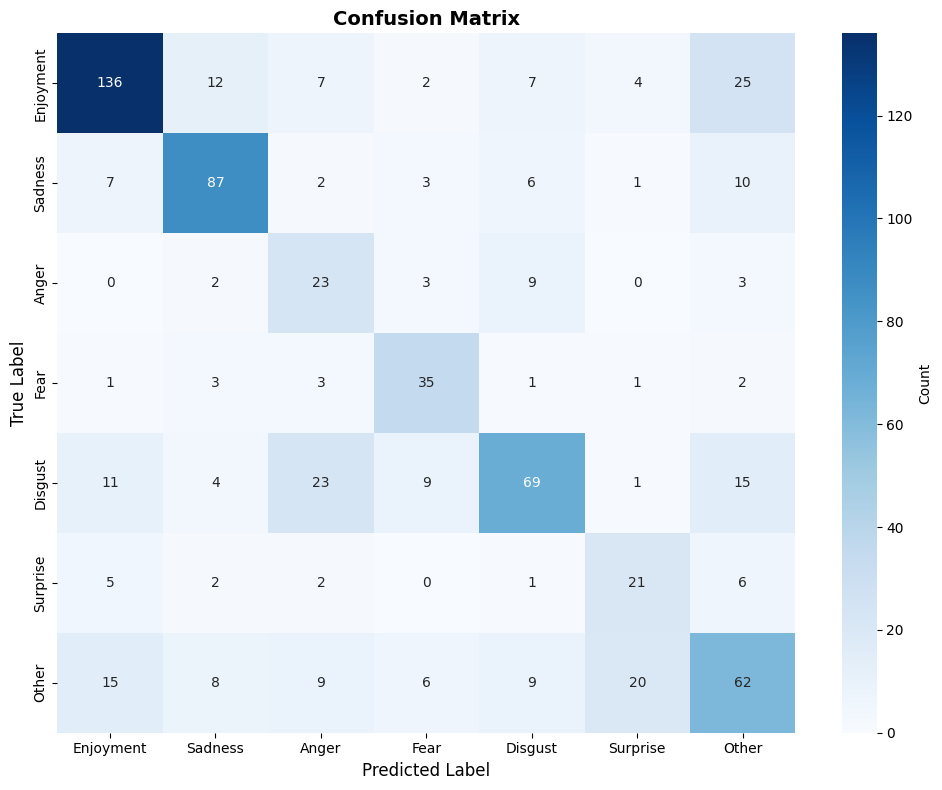

In [12]:
import os, torch, copy
import pandas as pd
os.chdir(REPO_DIR)

from src.data.dataset import EmotionDataset
from src.models.phobert_classifier import PhoBERTEmotionClassifier
from src.models.model_utils import save_model, get_device, print_model_summary
from src.training.trainer import train_model
from src.utils.config import load_all_configs
from src.utils.logger import setup_logger
from src.utils.metrics import compute_metrics, print_metrics, plot_confusion_matrix
import numpy as np
from pathlib import Path

logger = setup_logger(name='colab_training')

# Load configs
configs         = load_all_configs(CONFIG_DIR)
model_config    = configs['model']
training_config = configs['training']

logger.info(f"Model         : {model_config['model']['name']}")
logger.info(f"Epochs        : {training_config['training']['num_epochs']}")
logger.info(f"Batch size    : {training_config['training']['batch_size']}")
logger.info(f"LR            : {training_config['training']['learning_rate']}")
logger.info(f"Focal gamma   : {model_config['model'].get('focal_gamma', 2.0)}")

device = get_device()

# Paths
model_name      = model_config['model']['name']
max_len         = model_config['model']['max_seq_length']
VSMEC_ONLY_DIR  = f'{REPO_DIR}/data/processed/vsmec_only'
AUGMENTED_TRAIN = f'{PROCESSED_DIR}/train_augmented.csv'
STAGE1_DIR      = f'{CHECKPOINT_DIR}/stage1'

# Datasets — Stage 2 dùng augmented train
train_dataset = EmotionDataset(AUGMENTED_TRAIN,                   tokenizer_name=model_name, max_length=max_len)
val_dataset   = EmotionDataset(f'{PROCESSED_DIR}/validation.csv', tokenizer_name=model_name, max_length=max_len)
test_dataset  = EmotionDataset(f'{PROCESSED_DIR}/test.csv',       tokenizer_name=model_name, max_length=max_len)
vsmec_train   = EmotionDataset(f'{VSMEC_ONLY_DIR}/train.csv',     tokenizer_name=model_name, max_length=max_len)

logger.info(f"Train (augmented): {len(train_dataset)}, VSMEC-only: {len(vsmec_train)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Class weights — tính từ augmented train để phản ánh distribution mới
train_labels  = pd.read_csv(AUGMENTED_TRAIN)['label'].tolist()
class_counts  = np.bincount(train_labels, minlength=7).astype(float)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 7
print("Class weights (từ augmented train):")
for i, w in enumerate(class_weights):
    print(f"  {model_config['emotion_labels'][i]:<12}: {w:.3f}")

# Model
model = PhoBERTEmotionClassifier(
    model_name=model_name,
    num_labels=model_config['model']['num_labels'],
    dropout=model_config['model']['dropout'],
    class_weights=class_weights,
    label_smoothing=model_config['model'].get('label_smoothing', 0.0),
    focal_gamma=model_config['model'].get('focal_gamma', 2.0)
)
model.to(device)
print_model_summary(model)

# ── Curriculum Stage 1: VSMEC-only (clean foundation) ─────────────────────────
print("\n" + "=" * 50)
print("Stage 1: VSMEC-only — 10 epochs (clean data, no R-Drop)")
print("=" * 50)

stage1_config = copy.deepcopy(training_config)
stage1_config['training']['num_epochs']    = 10
stage1_config['training']['warmup_ratio']  = 0.2
stage1_config['training']['learning_rate'] = 1e-5  # Large model: 1e-5 (base dùng 2e-5 nhưng large cần nhỏ hơn)
stage1_config['training']['rdrop_alpha']   = 0.0   # Stage 1: tắt R-Drop để pretraining nhanh

train_model(
    model=model,
    train_dataset=vsmec_train,
    eval_dataset=val_dataset,
    training_config=stage1_config,
    output_dir=STAGE1_DIR,
    use_wandb=False
)

# ── Curriculum Stage 2: Augmented merged data + R-Drop ────────────────────────
print("\n" + "=" * 50)
print("Stage 2: Augmented merged data — 20 epochs (R-Drop enabled)")
print("=" * 50)

# Bật R-Drop chỉ cho Stage 2 (alpha=4.0 theo paper NeurIPS 2021)
training_config['training']['rdrop_alpha'] = 4.0

trainer = train_model(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    training_config=training_config,
    output_dir=CHECKPOINT_DIR,
    use_wandb=False
)

# Evaluate on test set
logger.info("Evaluating on test set...")
predictions = trainer.predict(test_dataset)
test_preds  = predictions.predictions
test_labels = predictions.label_ids

detailed = compute_metrics(test_preds, test_labels)
print_metrics(detailed, model_config['emotion_labels'])

# Confusion matrix
cm_path = Path(CHECKPOINT_DIR) / 'confusion_matrix.png'
plot_confusion_matrix(test_preds, test_labels,
                      emotion_labels=model_config['emotion_labels'],
                      save_path=cm_path)

# Save best model vào Drive
save_model(
    model=trainer.model,
    tokenizer=train_dataset.tokenizer,
    save_dir=BEST_MODEL_DIR,
    config={
        'model_config': model_config,
        'training_config': training_config,
        'test_results': {
            'accuracy':    detailed['accuracy'],
            'f1_macro':    detailed['f1_macro'],
            'f1_weighted': detailed['f1_weighted']
        }
    }
)

print("\n" + "=" * 50)
print("TRAINING HOÀN TẤT")
print("=" * 50)
print(f"Accuracy   : {detailed['accuracy']:.4f}")
print(f"F1-Macro   : {detailed['f1_macro']:.4f}")
print(f"F1-Weighted: {detailed['f1_weighted']:.4f}")
print(f"Model đã lưu tại: {BEST_MODEL_DIR}")

## Cell 7 — Kiểm tra model & test predict

In [13]:
import os
os.chdir(REPO_DIR)

from src.models.model_utils import load_model
from src.inference.predictor import EmotionPredictor

# Kiểm tra file đã lưu trong Drive
print("Files trong best_model:")
for f in sorted(os.listdir(BEST_MODEL_DIR)):
    size = os.path.getsize(f'{BEST_MODEL_DIR}/{f}') / 1024**2
    print(f"  {f:<30} {size:.1f} MB")

# Test predict
print("\nTest predict:")
predictor = EmotionPredictor(model_path=BEST_MODEL_DIR)

test_sentences = [
    "Hôm nay tôi rất vui vì được nghỉ học!",
    "Tôi buồn quá, không biết phải làm sao.",
    "Thật tức giận khi bị đối xử bất công.",
    "Trời ơi, tin này làm tôi bất ngờ quá!",
]

for sentence in test_sentences:
    result = predictor.predict(sentence)
    print(f"  Text      : {sentence}")
    print(f"  Emotion   : {result['emotion']}")
    print(f"  Confidence: {result['confidence']:.2%}")
    print()

Files trong best_model:
  added_tokens.json              0.0 MB
  bpe.codes                      1.1 MB
  config.yaml                    0.0 MB
  model.pt                       1410.4 MB
  tokenizer_config.json          0.0 MB
  vocab.txt                      0.9 MB

Test predict:
Loading model from /content/drive/MyDrive/MoodNote-AI/best_model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded from /content/drive/MyDrive/MoodNote-AI/best_model
Predictor initialized successfully!
  Text      : Hôm nay tôi rất vui vì được nghỉ học!
  Emotion   : Enjoyment
  Confidence: 53.78%

  Text      : Tôi buồn quá, không biết phải làm sao.
  Emotion   : Sadness
  Confidence: 98.13%

  Text      : Thật tức giận khi bị đối xử bất công.
  Emotion   : Anger
  Confidence: 41.49%

  Text      : Trời ơi, tin này làm tôi bất ngờ quá!
  Emotion   : Surprise
  Confidence: 91.66%

